# Spotify Mood Clustering
Mengelompokkan lagu berdasarkan karakteristik audio (energy, danceability, valence, dll)

**Sumber Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data),  Maharshi Pandya, Kaggle (2022):

**Alasan dapat digunakan sebagai Clustering:**
> "Spotify Tracks Dataset dipilih karena menyediakan sejumlah fitur audio numerik (danceability, energy, loudness, dan lainnya) yang merepresentasikan karakteristik musik secara objektif, sehingga sesuai untuk digunakan dalam proses clustering tanpa memerlukan label. Dengan jumlah data yang besar (114.000 baris) dan kondisi data yang relatif bersih, dataset ini memungkinkan pembentukan kelompok (cluster) yang dapat diinterpretasikan secara bermakna, serta dievaluasi kualitasnya baik secara kuantitatif (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index) maupun kualitatif melalui perbandingan dengan genre asli lagu."


## 1. Business Understanding

Spotify dan platform musik sejenis menyimpan jutaan lagu dengan genre yang sangat beragam. Masalahnya, genre saja sering tidak cukup untuk menggambarkan suasana atau mood sebuah lagu. Dua lagu dengan genre yang sama bisa terdengar sangat berbeda nuansanya. Karena itu, proyek ini mencoba mengelompokkan lagu langsung dari karakteristik audionya, bukan dari label genre yang sudah ada.

Tujuannya, hasil pengelompokan ini bisa dipakai sebagai dasar rekomendasi playlist berbasis mood (misalnya "energetic", "chill/acoustic", "instrumental"), membantu memahami pola alami yang muncul dari data audio, dan menjadi fondasi untuk fitur discovery atau rekomendasi lagu yang lebih personal.

Secara teknis, ini dilakukan dengan menerapkan algoritma K-Means pada fitur-fitur audio numerik (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo) untuk menemukan kelompok lagu dengan karakteristik mirip, murni tanpa menggunakan label genre sebagai acuan.

Cluster yang terbentuk dianggap berhasil kalau memenuhi tiga hal: kualitasnya cukup baik secara statistik (dicek dengan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index), hasilnya masuk akal saat diinterpretasikan (ada kelompok "energic", ada kelompok "acoustic", bukan kelompok acak tanpa makna), dan modelnya bisa dipakai untuk memprediksi cluster dari lagu baru lewat aplikasi deployment.

Fokus analisis ini dibatasi hanya pada fitur audio, popularitas dan metadata lagu (artis, judul, dll) sengaja tidak dipakai karena tujuannya mengelompokkan berdasarkan karakter bunyi musik, bukan seberapa populer atau siapa penyanyinya. Genre asli (`track_genre`) juga tidak dipakai sebagai fitur, hanya digunakan di akhir sebagai pembanding untuk validasi hasil cluster.

In [1]:
# Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 2. Data Understanding

In [2]:
# Load Dataset
df = pd.read_csv("dataset.csv", index_col=0)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Cek ukuran data (jumlah baris & kolom)
df.shape

(114000, 20)

In [4]:
# Cek Struktur Data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [5]:
# cek statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000


> **Insight:**
> - Dataset asli terdiri dari **114.000 baris dan 20 kolom**
> - Ada 6 kolom bertipe teks/kategorikal (`artists`, `album_name`, `track_name`, `explicit`, `track_genre`, dan `track_id` sebagai identifier), sisanya numerik.
> - Skala antar fitur numerik **sangat berbeda jauh**: sebagian besar fitur audio (`danceability`, `energy`, dll) berkisar 0–1, sementara `loudness` dalam desibel (rentang negatif hingga mendekati 0) dan `tempo` dalam BPM (puluhan–ratusan). Ini artinya **scaling wajib dilakukan** sebelum clustering.
> - Rata-rata `popularity` hanya ~33 dari skala 0–100, menunjukkan sebagian besar lagu di dataset ini tidak terlalu populer (distribusi condong ke nilai rendah).

## 3. Data Cleaning


Langkah cleaning yang dilakukan:
1. Cek missing value
2. Cek duplikasi berdasarkan `track_id` (satu lagu bisa muncul di banyak baris karena dilabeli beberapa `track_genre` berbeda)
3. Dedupe berdasarkan `track_id` supaya tiap lagu hanya dihitung sekali di ruang fitur, menghindari cluster bias ke lagu yang kebetulan multi-genre
4. Drop kolom yang tidak relevan sebagai fitur (ID, teks bebas)

In [6]:
print("Missing value per kolom:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nJumlah baris duplikat berdasarkan track_id:", df.duplicated(subset=["track_id"]).sum())
print("Jumlah unique track_id:", df["track_id"].nunique())

Missing value per kolom:
artists       1
album_name    1
track_name    1
dtype: int64

Jumlah baris duplikat berdasarkan track_id: 24259
Jumlah unique track_id: 89741


In [7]:
# Drop baris dengan missing value (jumlahnya sangat sedikit)
df_clean = df.dropna().copy()

# Dedupe: satu track_id hanya diambil satu kali (baris pertama)
df_clean = df_clean.drop_duplicates(subset=["track_id"], keep="first").reset_index(drop=True)

print("Shape setelah cleaning:", df_clean.shape)

Shape setelah cleaning: (89740, 20)


## 4. Exploratory Data Analysis (EDA)

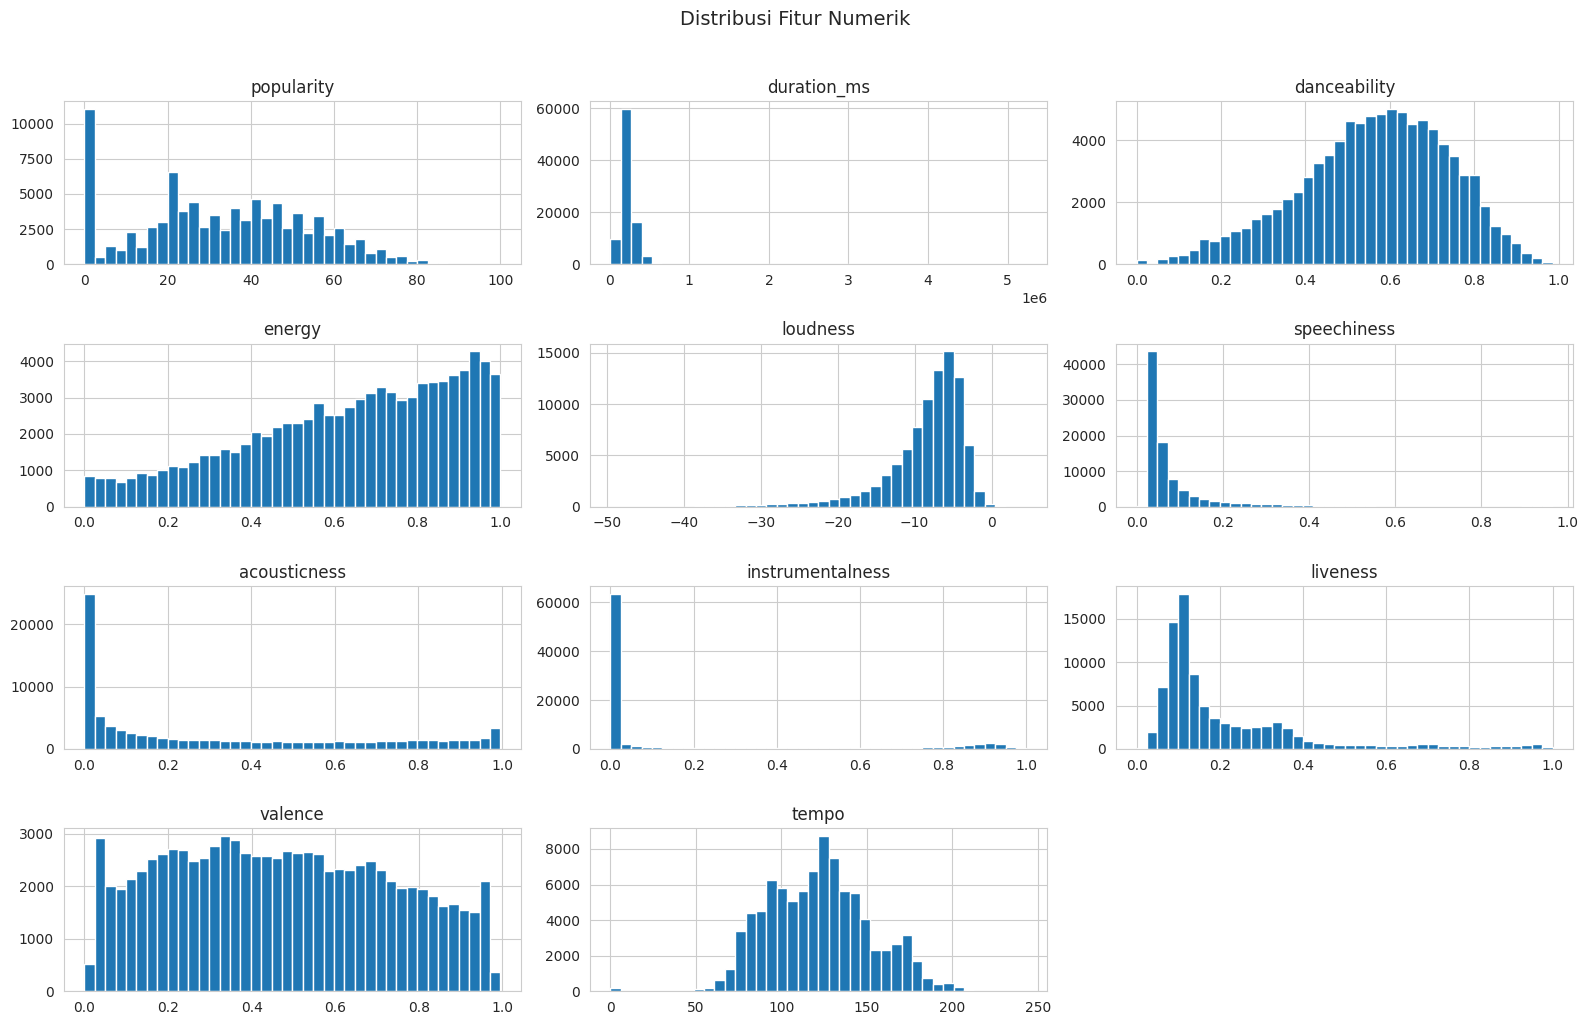

In [8]:
numeric_cols_all = ["popularity", "duration_ms", "danceability", "energy", "loudness",
                     "speechiness", "acousticness", "instrumentalness", "liveness",
                     "valence", "tempo"]

df_clean[numeric_cols_all].hist(figsize=(16, 10), bins=40)
plt.suptitle("Distribusi Fitur Numerik", y=1.02, fontsize=14)
plt.tight_layout()

plt.show()

> **Insight:**
> Dari histogram, sebagian besar fitur audio numerik tidak berdistribusi normal. `duration_ms` menunjukkan skew paling ekstrem, mayoritas lagu berdurasi sekitar 200 ribu ms dengan ekor panjang hingga 5 juta ms. Pola serupa (menumpuk di nilai rendah dengan ekor panjang ke kanan) juga terlihat pada `speechiness`, `instrumentalness`, `acousticness`, dan `liveness`, yang cukup masuk akal karena mayoritas lagu dalam dataset bukan berupa spoken word maupun instrumental murni.
>
> Sebaliknya, `energy` dan `loudness` justru skew ke kiri: mayoritas lagu dalam dataset ini tergolong energik dan cukup keras, sementara lagu bertenaga rendah hanya sebagian kecil. Fitur `valence` relatif merata di seluruh rentang 0 sampai 1, menunjukkan variasi mood lagu (sedih hingga ceria) yang cukup seimbang. Sementara itu, `popularity` memiliki bentuk yang lebih kompleks, ditandai lonjakan besar di nilai 0 (lagu yang hampir tidak pernah diputar) yang diikuti gundukan lain di rentang 20-50, sehingga distribusinya tidak sesederhana pola right-skewed biasa.

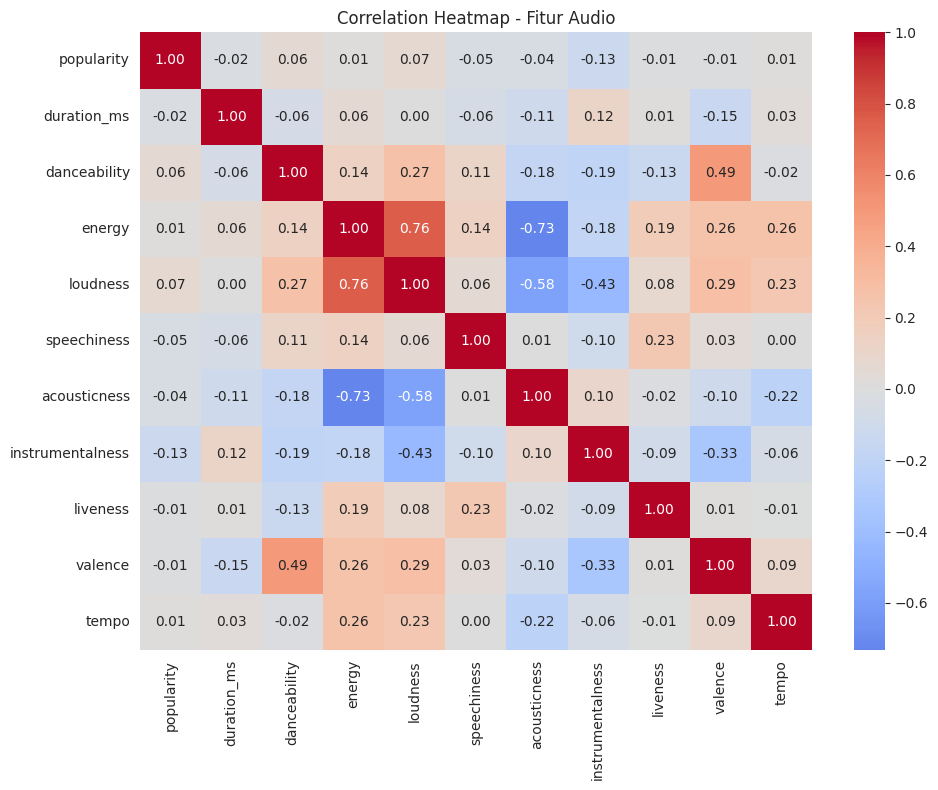

In [9]:
plt.figure(figsize=(10, 8))
corr = df_clean[numeric_cols_all].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Fitur Audio")
plt.tight_layout()

plt.show()

> **Insight:**
> Dari correlation heatmap, `energy` dan `loudness` menunjukkan korelasi positif terkuat (r = 0.76), sejalan dengan intuisi bahwa lagu yang lebih keras cenderung lebih energik. `energy` dan `acousticness` berkorelasi negatif cukup kuat (r = -0.73), mengindikasikan lagu akustik umumnya memiliki energi rendah. `danceability` dan `valence` berkorelasi positif sedang (r = 0.49), lagu yang mudah digunakan untuk menari cenderung memiliki mood lebih positif. Tidak ditemukan korelasi di atas 0.9 antar fitur.

## 5. Feature Selection

Fitur yang dipakai untuk clustering:

`danceability`, `energy`, `acousticness`, `valence`, `loudness`, `instrumentalness`

Keenam fitur ini merepresentasikan dimensi mood inti sebuah lagu: energi (`energy`, `loudness`), mood positif/negatif (`valence`), akustik/elektronik (`acousticness`), ritme (`danceability`), dan instrumental/vokal (`instrumentalness`).

Fitur yang **tidak digunakan** beserta alasannya:
- `popularity` → mencerminkan popularitas, bukan karakteristik musikal
- `duration_ms` → durasi teknis, tidak merepresentasikan mood
- `key`, `mode`, `time_signature` → bersifat kategorikal, kurang cocok untuk jarak Euclidean
- `speechiness`, `liveness`, `tempo` → menurunkan kualitas cluster berdasarkan eksperimen
- `track_genre` → disimpan terpisah untuk validasi eksternal, bukan sebagai fitur input
- `track_id`, `artists`, `album_name`, `track_name` → identifier/teks bebas

In [10]:
feature_cols = ["danceability", "energy", "acousticness", "valence", "loudness", "instrumentalness"]

X = df_clean[feature_cols].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,89740.0,0.562166,0.176692,0.000,0.45000,0.576000,0.692000,0.985
energy,89740.0,0.634458,0.256606,0.000,0.45700,0.676000,0.853000,1.000
acousticness,89740.0,0.328285,0.338321,0.000,0.01710,0.188000,0.625000,0.996
valence,89740.0,0.469474,0.262864,0.000,0.24900,0.457000,0.682000,0.995
loudness,89740.0,-8.498994,5.221518,-49.531,-10.32225,-7.185000,-5.108000,4.532
instrumentalness,89740.0,0.173415,0.323849,0.000,0.00000,0.000058,0.097625,1.000


In [11]:
X.head()

,danceability,energy,acousticness,valence,loudness,instrumentalness
0,0.676,0.4610,0.0322,0.715,-6.746,0.000001
1,0.420,0.1660,0.9240,0.267,-17.235,0.000006
2,0.438,0.3590,0.2100,0.120,-9.734,0.000000
3,0.266,0.0596,0.9050,0.143,-18.515,0.000071
4,0.618,0.4430,0.4690,0.167,-9.681,0.000000


## 6. Preprocessing (Scaling)

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,89740.0,-7.449060e-16,1.000006,-3.181635,-0.634816,0.078293,0.734806,2.393068
energy,89740.0,-2.026955e-17,1.000006,-2.472511,-0.691563,0.161889,0.851665,1.424530
acousticness,89740.0,-2.533694e-18,1.000006,-0.970342,-0.919798,-0.414653,0.877028,1.973627
valence,89740.0,-3.293802e-17,1.000006,-1.786011,-0.838746,-0.047456,0.808506,1.999245
loudness,89740.0,2.077629e-16,1.000006,-7.858297,-0.349183,0.251651,0.649430,2.495647
instrumentalness,89740.0,-1.013477e-17,1.000006,-0.535485,-0.535485,-0.535306,-0.234031,2.552389


In [13]:
X_scaled.head()

,danceability,energy,acousticness,valence,loudness,instrumentalness
0,0.644253,-0.675975,-0.875166,0.934047,0.335727,-0.535482
1,-0.804604,-1.825602,1.760810,-0.770269,-1.673087,-0.535468
2,-0.702731,-1.073473,-0.349626,-1.329497,-0.236524,-0.535485
3,-1.676182,-2.240247,1.704650,-1.241999,-1.918228,-0.535266
4,0.315996,-0.746122,0.415925,-1.150696,-0.226373,-0.535485


> **Insight:**
> Setelah scaling dengan `StandardScaler`, seluruh fitur sekarang punya mean mendekati 0 dan standar deviasi 1, sehingga skalanya seragam dan tidak ada fitur yang mendominasi perhitungan jarak di K-Means hanya karena rentang nilainya lebih besar (misalnya `loudness` yang tadinya dalam desibel, jauh berbeda skala dari fitur lain yang 0-1).

## 7. Modeling

Tahap modeling ini dibagi jadi tiga bagian:
1. Elbow Method, untuk mencari k optimal berdasarkan inertia
2. Silhouette Score, untuk mencari k optimal berdasarkan kualitas pemisahan antar cluster
3. Fit model final dengan KMeans, menggunakan k yang sudah dipilih dari dua langkah sebelumnya

### Elbow Method

In [14]:
k_range = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k} | inertia={km.inertia_:.1f}")

k=2 | inertia=369730.9
k=3 | inertia=302615.8
k=4 | inertia=251420.0
k=5 | inertia=212661.8
k=6 | inertia=196046.8
k=7 | inertia=182397.6
k=8 | inertia=170512.4
k=9 | inertia=161073.0
k=10 | inertia=152565.9


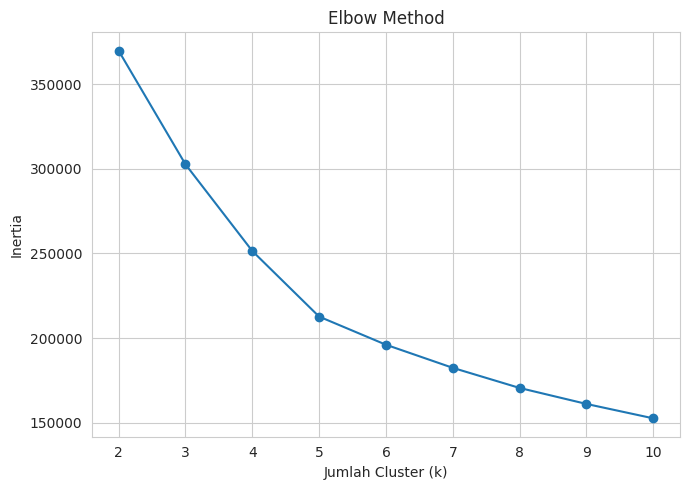

In [15]:
# Visualisasikan Elbow Method
plt.figure(figsize=(7, 5))

plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.tight_layout()

plt.show()

### Silhouette Score

Menghitung **Silhouette Score** untuk beberapa nilai k yang sama. Karena silhouette score mahal secara komputasi pada data besar, dihitung menggunakan sampel (8.000 baris).

In [16]:
silhouette_scores = []
sample_idx = X_scaled.sample(n=8000, random_state=RANDOM_STATE).index

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled.loc[sample_idx], labels[sample_idx])
    silhouette_scores.append(sil)
    print(f"k={k} | silhouette(sample)={sil:.4f}")

k=2 | silhouette(sample)=0.3468
k=3 | silhouette(sample)=0.2379
k=4 | silhouette(sample)=0.2520
k=5 | silhouette(sample)=0.2642
k=6 | silhouette(sample)=0.2367
k=7 | silhouette(sample)=0.2305
k=8 | silhouette(sample)=0.2339
k=9 | silhouette(sample)=0.2348
k=10 | silhouette(sample)=0.2144


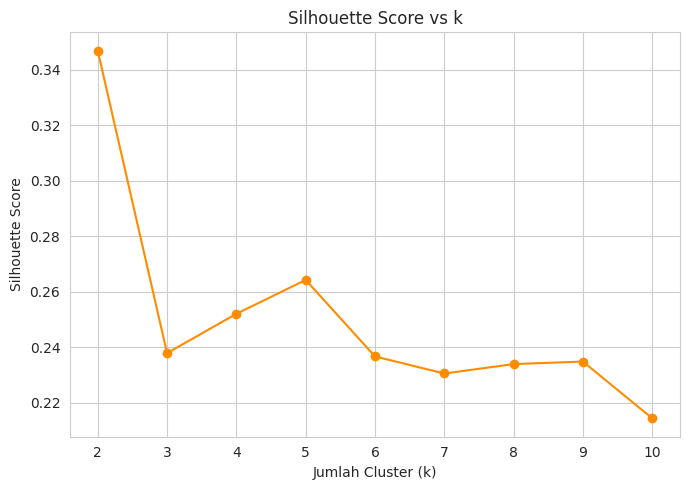

In [17]:
# Visualisasikan Silhouette Score
plt.figure(figsize=(7, 5))

plt.plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
plt.title("Silhouette Score vs k")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()

plt.show()

> **Insight:**
> - Dari Elbow Method, penurunan inertia mulai melandai di sekitar k=5-6, menandakan penambahan cluster setelah titik ini tidak lagi memberikan perbaikan yang signifikan.
> - Dari Silhouette Score, k=2 memang punya nilai tertinggi (0.3468), tapi di-exclude karena hanya membagi data jadi dua kelompok besar yang terlalu general untuk tujuan segmentasi mood. Di luar k=2, k=5 punya silhouette tertinggi (0.2642), jauh lebih baik dibanding skema 9 fitur sebelumnya yang hanya mencapai 0.1948 pada k=7.
> - Kesimpulannya, k=5 dipilih karena merupakan local maximum yang jelas pada kurva silhouette, didukung juga oleh penurunan inertia yang mulai melandai di titik yang sama, sekaligus menghasilkan jumlah segmen yang praktis untuk merepresentasikan mood musik.

### Fit Model

In [18]:
K_FINAL = 5

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clean["cluster"] = cluster_labels
X_scaled["cluster"] = cluster_labels

print(df_clean["cluster"].value_counts().sort_index())

cluster
0    29851
1     6651
2    19591
3    10538
4    23109
Name: count, dtype: int64


> **Insight:**
> - Terbentuk **5 cluster** dengan distribusi yang cukup bervariasi.
> - Cluster 0 paling besar dengan 29.851 lagu (33.3%).
> - Cluster 4 (23.109 lagu, 25.8%) dan Cluster 2 (19.591 lagu, 21.8%) berukuran besar-menengah.
> - Cluster 3 (10.538 lagu, 11.7%) dan Cluster 1 (6.651 lagu, 7.4%) berukuran lebih kecil, kemungkinan merepresentasikan segmen mood yang lebih spesifik atau niche.
> - Tidak ada cluster yang berukuran sangat kecil secara ekstrem, menandakan pembagian yang cukup seimbang antar segmen.

## 8. Model Evaluation

In [19]:
eval_sample_idx = X_scaled.sample(n=15000, random_state=RANDOM_STATE).index
X_eval = X_scaled.loc[eval_sample_idx, feature_cols]
labels_eval = X_scaled.loc[eval_sample_idx, "cluster"]

sil = silhouette_score(X_eval, labels_eval)
db = davies_bouldin_score(X_scaled[feature_cols], X_scaled["cluster"])
ch = calinski_harabasz_score(X_scaled[feature_cols], X_scaled["cluster"])

print(f"Silhouette Score (sampel 15.000 baris) : {sil:.4f}")
print(f"Davies-Bouldin Index (seluruh data)     : {db:.4f}")
print(f"Calinski-Harabasz Index (seluruh data)  : {ch:.1f}")

Silhouette Score (sampel 15.000 baris) : 0.2660
Davies-Bouldin Index (seluruh data)     : 1.1723
Calinski-Harabasz Index (seluruh data)  : 34366.5


> **Insight:**
> - Silhouette Score sebesar 0.266 menunjukkan struktur cluster yang cukup terbentuk, meski belum masuk kategori "sangat jelas" (umumnya ambang di atas 0.5).
> - Davies-Bouldin Index sebesar 1.172 mengindikasikan pemisahan antar cluster yang cukup baik, semakin mendekati 0 semakin baik.
> - Calinski-Harabasz Index sebesar 34.366,5 menunjukkan variansi antar-cluster cukup dominan dibanding variansi di dalam cluster.
> - Ketiga metrik ini saling konsisten mendukung bahwa skema 6 fitur menghasilkan cluster yang cukup solid untuk digunakan.

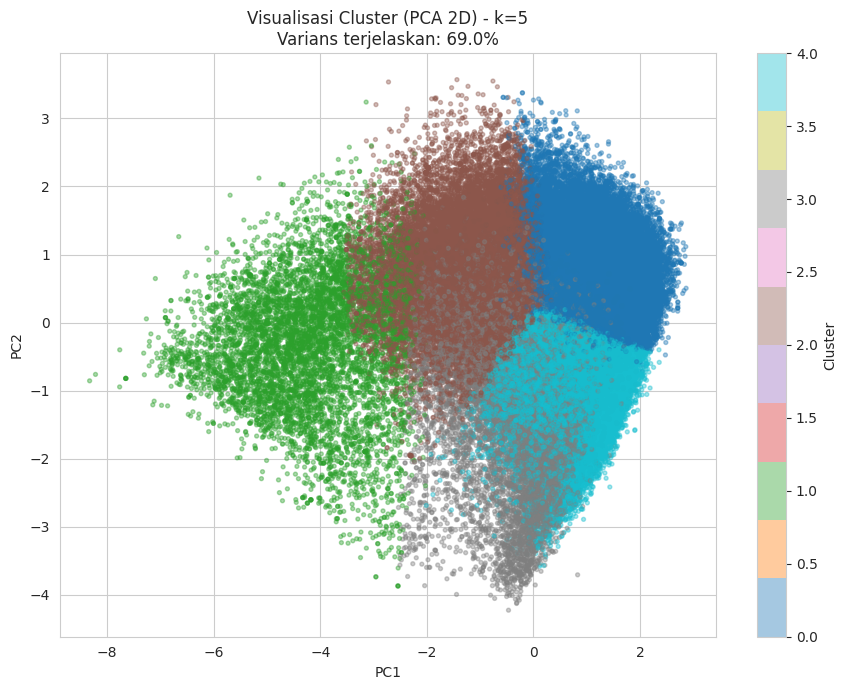

In [20]:
# Visualisasi cluster dalam 2D menggunakan PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca.fit_transform(X_scaled[feature_cols])

plt.figure(figsize=(9, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                       c=cluster_labels, cmap="tab10", alpha=0.4, s=8)
plt.title(f"Visualisasi Cluster (PCA 2D) - k={K_FINAL}\nVarians terjelaskan: {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

> **Insight:**
> - Visualisasi PCA 2D (dengan varians terjelaskan 69%) menunjukkan 5 cluster dengan pemisahan yang cukup terlihat, meski masih ada overlap di beberapa area, khususnya di sekitar pusat plot.
> - Cluster hijau (di sisi kiri) tampak paling terpisah dari kelompok lainnya.
> - Overlap yang muncul di antara beberapa cluster wajar terjadi karena PCA 2D hanya merepresentasikan 69% dari total varians data, sehingga sebagian informasi pemisahan yang sebenarnya ada di dimensi lain tidak tertangkap dalam plot ini.

## 9. Interpretasi & Profiling Cluster

Melihat rata-rata tiap fitur per cluster untuk memberi nama/label yang bermakna ke tiap cluster.

In [21]:
# Rata-rata tiap fitur per cluster, digunakan untuk melihat karakteristik masing-masing cluster
cluster_profile = df_clean.groupby("cluster")[feature_cols].mean().round(3)
cluster_profile["jumlah_lagu"] = df_clean["cluster"].value_counts().sort_index()
cluster_profile

,danceability,energy,acousticness,valence,loudness,instrumentalness,jumlah_lagu
cluster,,,,,,,
0,0.696,0.727,0.231,0.718,-6.467,0.020,29851
1,0.341,0.176,0.859,0.179,-21.323,0.784,6651
2,0.529,0.387,0.704,0.405,-10.790,0.032,19591
3,0.577,0.747,0.112,0.341,-8.434,0.794,10538
4,0.475,0.806,0.081,0.346,-5.521,0.033,23109


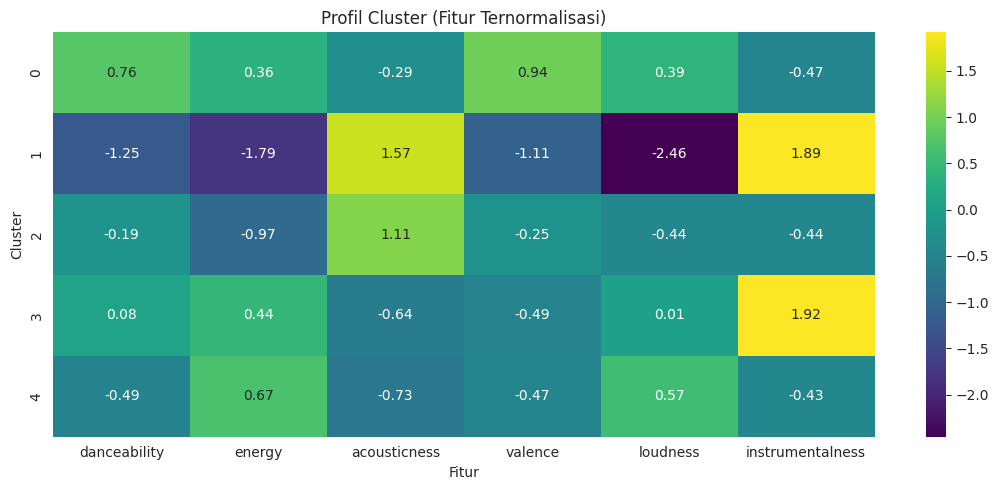

In [22]:
# Heatmap profil cluster (rata-rata fitur ternormalisasi per cluster)
profile_scaled = X_scaled.groupby("cluster")[feature_cols].mean()

plt.figure(figsize=(11, 5))
sns.heatmap(profile_scaled, annot=True, fmt=".2f", cmap="viridis")
plt.title("Profil Cluster (Fitur Ternormalisasi)")
plt.xlabel("Fitur")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

> **Insight:**
> Profil 5 cluster menunjukkan karakter yang cukup berbeda satu sama lain.
> - Cluster 0 (29.851 lagu): danceability, energy, dan valence semuanya tinggi, acousticness rendah. Karakter ini dinamai Upbeat/Danceable/Happy.
> - Cluster 1 (6.651 lagu): acousticness tertinggi, energy dan loudness terendah, valence juga terendah. Karakter ini dinamai Instrumental/Ambient/Calm.
> - Cluster 2 (19.591 lagu): acousticness tinggi, energy tergolong rendah (meski tidak serendah Cluster 1), valence mendekati rata-rata. Karakter ini dinamai Acoustic/Mellow.
> - Cluster 3 (10.538 lagu): instrumentalness tertinggi di antara seluruh cluster, tapi energy-nya juga tinggi, berbeda dari Cluster 1 yang cenderung kalem. Karakter ini dinamai Instrumental/Electronic (Energic).
> - Cluster 4 (23.109 lagu): energy dan loudness tertinggi, acousticness terendah. Karakter ini dinamai High-Energy/Intense.

In [26]:
# Validasi eksternal: genre dominan di tiap cluster
top_genre_per_cluster = (
    df_clean.groupby("cluster")["track_genre"]
    .apply(lambda x: x.value_counts().head(5))
)
top_genre_per_cluster

cluster                
0        salsa             869
         forro             846
         kids              795
         dancehall         781
         disco             662
1        sleep             805
         new-age           769
         ambient           663
         classical         624
         iranian           434
2        tango             861
         honky-tonk        776
         romance           748
         cantopop          720
         comedy            640
3        minimal-techno    770
         detroit-techno    731
         study             607
         grindcore         553
         chicago-house     517
4        heavy-metal       868
         grunge            698
         hardstyle         685
         metalcore         684
         death-metal       661
Name: track_genre, dtype: int64

> **Insight (Validasi Eksternal):**
> Genre dominan tiap cluster selaras dengan interpretasi audio-feature yang sudah dibuat sebelumnya.
> - Cluster 0 (Upbeat/Danceable): salsa, forro, kids, dancehall, disco. Genre-genre ini memang identik dengan musik untuk joget atau suasana ceria.
> - Cluster 1 (Instrumental/Ambient/Calm): sleep, new-age, ambient, classical, iranian. Genre ini cocok sempurna dengan karakter tenang dan minim vokal.
> - Cluster 2 (Acoustic/Mellow): tango, honky-tonk, romance, cantopop, comedy. Nuansa akustik dan romantis terlihat jelas di genre-genre ini.
> - Cluster 3 (Instrumental/Electronic Energic): minimal-techno, detroit-techno, study, grindcore, chicago-house. Genre ini mencerminkan karakter elektronik instrumental yang tetap berenergi tinggi.
> - Cluster 4 (High-Energy/Intense): heavy-metal, grunge, hardstyle, metalcore, death-metal. Genre ini cocok sempurna dengan karakter energi tinggi dari cluster ini.
>
> Validasi eksternal ke genre asli (yang tidak dipakai saat proses training) mengonfirmasi bahwa clustering berhasil menangkap pola mood dan karakter musik yang bermakna secara musikal.

## 10. Simpan Model untuk Deployment

In [23]:
# Ambil beberapa lagu representatif per cluster (diurutkan dari yang paling populer)
songs_per_cluster = (
    df_clean[["track_id", "track_name", "artists", "popularity", "track_genre", "cluster"]]
    .sort_values("popularity", ascending=False)
    .groupby("cluster")
    .head(15)
    .reset_index(drop=True)
)

songs_per_cluster.to_csv("cluster_songs.csv", index=False)
print(f"Tersimpan {len(songs_per_cluster)} lagu contoh ke cluster_songs.csv")
songs_per_cluster.head(10)

Tersimpan 75 lagu contoh ke cluster_songs.csv


,track_id,track_name,artists,popularity,track_genre,cluster
0,3nqQXoyQOWXiESFLlDF1hG,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,dance,4
1,2tTmW7RDtMQtBk7m2rYeSw,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop,0
2,4uUG5RXrOk84mYEfFvj3cK,I'm Good (Blue),David Guetta;Bebe Rexha,98,dance,4
3,5ww2BF9slyYgNOk37BlC4u,La Bachata,Manuel Turizo,98,latin,0
4,6Sq7ltF9Qa7SNFBsV5Cogx,Me Porto Bonito,Bad Bunny;Chencho Corleone,97,latin,0
5,1IHWl5LamUGEuP4ozKQSXZ,Tití Me Preguntó,Bad Bunny,97,latin,4
6,4h9wh7iOZ0GGn8QVp4RAOB,I Ain't Worried,OneRepublic,96,piano,0
7,5IgjP7X4th6nMNDh4akUHb,Under The Influence,Chris Brown,96,dance,4
8,5Eax0qFko2dh7Rl2lYs3bx,Efecto,Bad Bunny,96,latin,0
9,4LRPiXqCikLlN15c3yImP7,As It Was,Harry Styles,95,pop,0


In [24]:
import json

joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans_final, "kmeans_model.pkl")

with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

cluster_profile.to_csv("cluster_profile.csv")

print("Tersimpan: scaler.pkl, kmeans_model.pkl, feature_columns.json, cluster_profile.csv")

Tersimpan: scaler.pkl, kmeans_model.pkl, feature_columns.json, cluster_profile.csv


## Kesimpulan

- Dataset Spotify Tracks (114.000 baris menjadi 89.740 lagu unik setelah proses dedup) dikelompokkan menjadi 5 cluster berdasarkan 6 fitur audio inti: danceability, energy, acousticness, valence, loudness, dan instrumentalness.
- Skema 6 fitur ini dipilih setelah eksperimen menunjukkan bahwa fitur speechiness, liveness, dan tempo menurunkan kualitas cluster. Mengeluarkan ketiganya meningkatkan Silhouette Score dari sekitar 0.195 menjadi sekitar 0.266, sambil tetap jauh di atas syarat minimal 3 kolom numerik.
- Evaluasi model menunjukkan Silhouette Score sekitar 0.266, Davies-Bouldin Index sekitar 1.172, dan Calinski-Harabasz Index sekitar 34.366,5, yang secara konsisten menunjukkan struktur cluster yang cukup solid.
- Kelima cluster berhasil diberi nama yang bermakna: Upbeat/Danceable/Happy, Instrumental/Ambient/Calm, Acoustic/Mellow, Instrumental/Electronic (Energic), dan High-Energy/Intense.
- Validasi eksternal lewat genre asli lagu menunjukkan kesesuaian yang tinggi dengan interpretasi tiap cluster, memperkuat kredibilitas hasil clustering.
- Model disimpan (`scaler.pkl`, `kmeans_model.pkl`, `feature_columns.json`, `cluster_profile.csv`, `cluster_songs.csv`) dan siap dipakai untuk aplikasi rekomendasi mood-based berbasis Streamlit.

**Saran pengembangan lanjutan (opsional):**
- Bandingkan dengan algoritma lain seperti DBSCAN, Hierarchical Clustering, atau GMM untuk soft-clustering
- Coba skema fitur lain, misalnya 4-5 fitur, untuk melihat trade-off lebih lanjut antara kesederhanaan dan kekayaan interpretasi
- Perluas `cluster_songs.csv` menjadi sistem rekomendasi playlist otomatis berbasis cluster